# TorchSpin — `pepper` playground: simulate, then fit with every `esfit` method

Change the parameters in the first cells, run everything, and compare how the fitting methods recover
the truth from noisy data: which parameters they get right, how far off they land, and how long they take.

Sections: 1. choose a spin system and experiment · 2. simulate + add noise · 3. define the fit model
and starting guess · 4. run all methods · 5. recovery table and plots · 6. robustness to the starting
guess and noise (optional, slower).

In [1]:
# setup: use the repository checkout if torchspin is not installed
import sys
from pathlib import Path
try:
    import torchspin  # noqa: F401
except ImportError:
    _root = Path.cwd()
    while not (_root / 'torchspin').exists() and _root != _root.parent:
        _root = _root.parent
    sys.path.insert(0, str(_root))

In [2]:
import time, numpy as np, matplotlib.pyplot as plt, torch
from torchspin import SpinSystem, Experiment, Options, pepper, esfit
from torchspin.esfit import FitOptions
rng = np.random.default_rng(1)
torch.set_num_threads(min(torch.get_num_threads(), 32))   # the pools inside pepper scale to ~32 cores; more only oversubscribes
print('torch threads', torch.get_num_threads())

torch threads 32


## 1. Spin system and experiment (edit me)

In [3]:
# --- ground truth ---
TRUE = dict(g=[2.0085, 2.0060, 2.0025], A=[18.0, 18.0, 92.0], lwpp=0.35)   # nitroxide-like; A in MHz, lwpp in mT
NUC = '14N'
exp = Experiment(mwFreq=9.5, Range=[330, 350], nPoints=1024, Harmonic=1)
GRID = [31, 4]                     # SOPHE knots × interpolation factor (accuracy vs speed)
NOISE = 0.02                       # relative to the peak amplitude
# which parameters to fit: name -> (true value, half-width of the search box)
FIT = {'gx': (TRUE['g'][0], 0.004), 'gy': (TRUE['g'][1], 0.004), 'gz': (TRUE['g'][2], 0.004), 'Az': (TRUE['A'][2], 15.0), 'lwpp': (TRUE['lwpp'], 0.25)}
START_OFFSET = 0.6                 # start at truth + START_OFFSET × half-width (0 = start at the truth)

## 2. Simulate and add noise

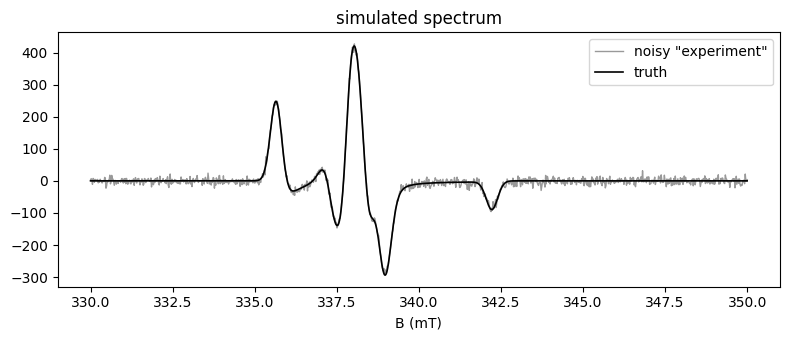

In [4]:
def simulate(g, A, lwpp):
    s = SpinSystem(S=[0.5], g=list(g), Nucs=NUC, A=[list(A)], lwpp=[lwpp, 0])
    return pepper(s, exp, Options(Verbosity=0, GridSize=GRID))

B, y_true = simulate(TRUE['g'], TRUE['A'], TRUE['lwpp'])
B, y_true = B.numpy(), y_true.numpy()
data = y_true + NOISE * np.abs(y_true).max() * rng.standard_normal(y_true.shape)
plt.figure(figsize=(8, 3.5)); plt.plot(B, data, '0.6', lw=1, label='noisy "experiment"'); plt.plot(B, y_true, 'k', lw=1.2, label='truth')
plt.xlabel('B (mT)'); plt.legend(); plt.title('simulated spectrum'); plt.tight_layout()

## 3. Fit model and starting guess

The model maps a parameter vector (in the order of `FIT`) to a spectrum; `esfit` rescales amplitude and baseline itself (`autoscale='lsq'`).

In [5]:
names = list(FIT)
p_true = np.array([FIT[k][0] for k in names]); vary = np.array([FIT[k][1] for k in names])
p0 = p_true + START_OFFSET * vary

def model(p):
    P = dict(zip(names, p))
    g = [P.get('gx', TRUE['g'][0]), P.get('gy', TRUE['g'][1]), P.get('gz', TRUE['g'][2])]
    A = [P.get('Ax', TRUE['A'][0]), P.get('Ay', TRUE['A'][1]), P.get('Az', TRUE['A'][2])]
    return simulate(g, A, P.get('lwpp', TRUE['lwpp']))[1].numpy()

t = time.perf_counter(); model(p0); print(f'one forward call: {time.perf_counter() - t:.3f} s')
print('start  ', dict(zip(names, np.round(p0, 4))))

one forward call: 0.072 s
start   {'gx': np.float64(2.0109), 'gy': np.float64(2.0084), 'gz': np.float64(2.0049), 'Az': np.float64(101.0), 'lwpp': np.float64(0.5)}


## 4. Run the fitting methods

`simplex`, `powell`, `lbfgsb` and `levmar` are local; `swarm`, `genetic`, `montecarlo` and `grid` are global; `global` = swarm followed by a simplex polish (the recommended default).  Population methods use `n_workers` processes when > 1.

Parallelism: the simulators themselves already use all cores (thread pools inside `pepper`); the population methods additionally spread their members over `n_workers` processes (`'auto'` = one per core), each with one torch thread.

Progress: `progress='text'` prints a resource line when each fit starts (torch threads, worker processes, CPUs, device, memory), a status line every `progress_interval` seconds (iteration, evaluations, current and best RMSD, elapsed, evaluations/s, ETA) and a totals line at the end. Interrupting the kernel returns the best fit so far (`res.interrupted` is True); `max_time` and `stop_when` do the same automatically.

In [6]:
METHODS = {
    'simplex':    FitOptions(method='simplex'),
    'powell':     FitOptions(method='powell'),
    'lbfgsb':     FitOptions(method='lbfgsb'),
    'levmar':     FitOptions(method='levmar'),
    'swarm':      FitOptions(method='swarm', swarm_size=24, max_iter=25),
    'genetic':    FitOptions(method='genetic', ga_population=24, max_iter=25),
    'montecarlo': FitOptions(method='montecarlo', mc_samples=400),
    'global':     FitOptions(method='global', swarm_size=24, max_iter=25),
}
N_WORKERS = 'auto'   # population methods: one worker process per core ('auto'), an int, or 1 for sequential;
                     # a model defined in a notebook cell reaches the workers via cloudpickle (pip install cloudpickle)
results = {}
for name, opts in METHODS.items():
    opts.verbosity = 0; opts.compute_uncertainties = False; opts.n_workers = N_WORKERS; opts.seed = 7
    opts.progress = 'text'; opts.progress_interval = 5.0     # 'bar' gives a tqdm bar where tqdm is installed
    try:
        res = esfit(data, model, p0, vary=vary, options=opts)
        fit = np.asarray(res.fit, float)
        results[name] = dict(pfit=np.asarray(res.pfit, float), fit=fit, rmsd=float(np.sqrt(np.mean((fit - data) ** 2))), time=res.elapsed_s, nfev=res.n_evaluations)
        print(f'{name:11s} {res.elapsed_s:6.1f} s  {res.n_evaluations:5d} evals  rmsd {results[name]["rmsd"]:.3e}')
        if res.interrupted:
            print(f'{name}: interrupted, keeping the best fit so far'); break   # drop the break to continue with the next method
    except Exception as e:
        print(f'{name:11s} failed: {e}')

esfit[simplex] 5 params, 1024 points | torch threads 32 | workers serial | cpus 128 | cuda yes, mps no | rss 639 MB


  [simplex]  iter 24  eval 48  rmsd 8.991e+02  best 8.866e+02  5.1 s  9.5 ev/s


  [simplex]  iter 60  eval 105  rmsd 4.147e+02  best 4.035e+02  10.2 s  10.3 ev/s


  [simplex]  iter 92  eval 159  rmsd 2.951e+02  best 2.951e+02  15.2 s  10.5 ev/s


  [simplex]  iter 120  eval 211  rmsd 2.932e+02  best 2.932e+02  20.2 s  10.4 ev/s


...

  [global/simplex]  iter 81  eval 655  rmsd 2.648e+02  best 2.648e+02  20.3 s  32.2 ev/s


  [global/simplex]  iter 111  eval 707  rmsd 2.648e+02  best 2.648e+02  25.3 s  27.9 ev/s


  [global/simplex]  iter 141  eval 759  rmsd 2.648e+02  best 2.648e+02  30.4 s  25.0 ev/s


esfit[global] done: 766 evals, 31.1 s, 24.6 ev/s, best rmsd 2.648e+02, rss 690 MB (+12 MB)


global        31.1 s    766 evals  rmsd 9.093e+00


## 5. Recovery table and plots

Errors are given in units of the search half-width (`vary`), so 1.0 means the method ended at the edge of the box; the noise floor sets what 'right' means (the truth's own RMSD is shown for reference).

In [7]:
rmsd_truth = float(np.sqrt(np.mean((y_true - data) ** 2)))
print('rmsd of a fit close to the noise floor ≈ rmsd(truth); local methods here stop at the gx↔gy-swapped saddle')
print('truth:', {k: round(v, 5) for k, v in zip(names, p_true)}, f'  rmsd(truth) = {rmsd_truth:.3e}')
err = {m: np.abs(r['pfit'] - p_true) / vary for m, r in results.items()}          # error in units of the search half-width
order = sorted(results, key=lambda m: err[m].max())
hdr = f"{'method':11s} " + ' '.join(f'{k:>9s}' for k in names) + '   max|err|/vary  rmsd/rmsd(truth)   time (s)'
print(hdr); print('-' * len(hdr))
for m in order:
    r = results[m]
    print(f'{m:11s} ' + ' '.join(f'{v:9.4f}' for v in r['pfit']) + f'   {err[m].max():13.3f}  {r["rmsd"] / rmsd_truth:16.3f}   {r["time"]:8.1f}')

rmsd of a fit close to the noise floor ≈ rmsd(truth); local methods here stop at the gx↔gy-swapped saddle
truth: {'gx': np.float64(2.0085), 'gy': np.float64(2.006), 'gz': np.float64(2.0025), 'Az': np.float64(92.0), 'lwpp': np.float64(0.35)}   rmsd(truth) = 8.350e+00
method             gx        gy        gz        Az      lwpp   max|err|/vary  rmsd/rmsd(truth)   time (s)
----------------------------------------------------------------------------------------------------------
swarm          2.0085    2.0060    2.0026   91.3354    0.3298           0.081             1.108        5.9
montecarlo     2.0085    2.0059    2.0025   91.6193    0.3222           0.111             1.089      157.9
global         2.0085    2.0059    2.0025   91.6175    0.3222           0.111             1.089       31.1
lbfgsb         2.0085    2.0059    2.0025   91.6169    0.3222           0.111             1.089       35.6
genetic        2.0086    2.0060    2.0021   95.4578    0.3272           0.231             2

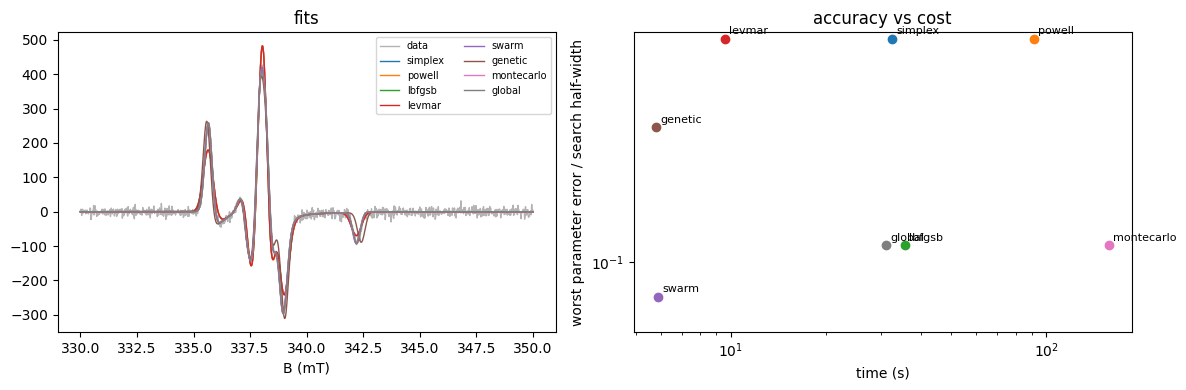

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(B, data, '0.7', lw=1, label='data')
for m, r in results.items():
    axes[0].plot(B, r['fit'], lw=1, label=m)
axes[0].set_xlabel('B (mT)'); axes[0].legend(fontsize=7, ncol=2); axes[0].set_title('fits')
for m, r in results.items():
    axes[1].scatter(r['time'], err[m].max()); axes[1].annotate(m, (r['time'], err[m].max()), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].set_xscale('log'); axes[1].set_yscale('symlog', linthresh=1e-3); axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('worst parameter error / search half-width'); axes[1].set_title('accuracy vs cost')
plt.tight_layout()

## 6. Robustness: starting guess and noise (optional)

Repeats a subset of methods from several random starting points inside the box and reports how often each lands within 15 % of the box half-width of the truth.  Reduce `N_STARTS` or the method list to keep it quick.

In [9]:
N_STARTS = 4
TOL = 0.15          # success: every parameter within 15 % of the search half-width (the 2 % noise limits lwpp/Az to a few %)
SUBSET = ['simplex', 'levmar', 'global']
hits = {m: 0 for m in SUBSET}; times = {m: [] for m in SUBSET}
for k in range(N_STARTS):
    p_start = p_true + rng.uniform(-1, 1, size=len(names)) * vary
    for m in SUBSET:
        opts = METHODS[m]; opts.verbosity = 0; opts.compute_uncertainties = False; opts.seed = 100 + k
        opts.progress = None; opts.max_time = 600      # quiet, but never let one restart run away
        t = time.perf_counter(); res = esfit(data, model, p_start, vary=vary, options=opts); times[m].append(time.perf_counter() - t)
        if np.all(np.abs(np.asarray(res.pfit) - p_true) / vary < TOL):
            hits[m] += 1
for m in SUBSET:
    print(f'{m:8s} success rate {hits[m] / N_STARTS:4.2f}   mean time {np.mean(times[m]):6.1f} s')

simplex  success rate 1.00   mean time   38.9 s
levmar   success rate 1.00   mean time    6.9 s
global   success rate 0.50   mean time   35.6 s


## Notes

* Degenerate minima: a powder spectrum without hyperfine coupling is invariant under permutations of the g principal values, and with an axial nucleus under gx ↔ gy; local methods started symmetrically may land on the mirror solution with the same residual.
* The forward model is differentiable too: see `02_gpu_and_autograd.ipynb` for gradient-based fits with `differentiable_spectrum`.
* Fitting real data: `05_fitting_real_world.ipynb`, `06_blue_copper_fitting.ipynb`.